### Continuous Stirred Tank Reactor PID Controller

Proportion (P): changes cooling jacket temperature based on how far the current reactor temperature is from the setpoint
Integral (I): removes steady-state temperature offsets accumulated over time
Derivatve (D): predicts future temperature trends to reduce overshoot, though it is often set to zero or a small value to avoid amplifying sensor noise

In [131]:
# This is my first time doing this on Python. 
# I am used to doing this on Simulink/MATLAB
# Here are some resources I followed: https://dganais.medium.com/pid-controllers-and-influxdb-part-2-digital-twin-170676ca453c
# https://dganais.medium.com/pid-controllers-and-influxdb-part-1-background-bf351c98677e

import numpy as np 
import matplotlib.pyplot as plt
#from scipy.integrate import odeint
from scipy.integrate import odeint

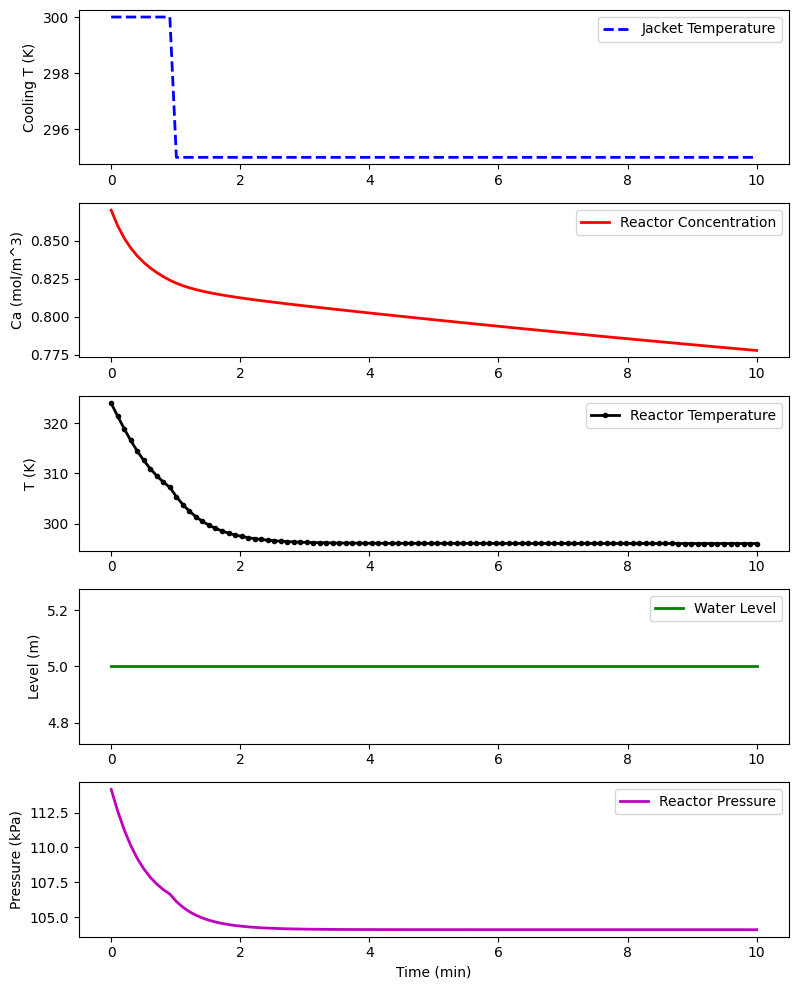

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters:
q = 2        # Volumetric Flowrate (m^3/sec) - inlet 
qout = 2      # Volumetric Flowrate (m^3/sec) - outlet
rho = 1000     # Density of Mixture (kg/m^3)
Cp = 0.239     # Heat capacity of Mixture (J/kg-K)
dH = 5e4       # Heat of reaction (J/mol)
EoverR = 8750  # E/R parameter (K)
k0 = 7.2e10    # Pre-exponential factor (1/sec)
UA = 5e4       # Heat Transfer Coefficient * Area (W/K)

# Tank Geometry for Water Level
A_tank = 20.0  # Tank cross-sectional area (m^2)

def cstr(x, t, u, Tf, Caf):
    Tc = u # assume constant coolant flow rate

    # Define the dynamic states 
    Ca = x[0]  # Concentration of A (mol/m^3)
    T = x[1]   # Temperature in CSTR (K)
    V_dyn = x[2] # Current dynamic liquid volume (m^3)

    rA = k0 * np.exp(-EoverR/T)*Ca # reaction rate
    
    # Calculate concentration derivative
    dCadt = (q/V_dyn)*(Caf - Ca) - rA
    
    # Corrected temperature derivative using dynamic volume V_dyn
    dTdt = (q*Tf - qout*T + (dH*rA*V_dyn)/(rho*Cp) - (UA*(T - Tc))/(rho*Cp))/V_dyn
    
    # Mass balance: evaluate volume derivative based on inlet and outlet flow rate 
    dVdt = q - qout

    # Return xdot:
    xdot = np.zeros(3)
    xdot[0] = dCadt
    xdot[1] = dTdt
    xdot[2] = dVdt
    return xdot

# Function to calculate vapor pressure via Antoine Equation
def get_pressure(T_kelvin):
    T_c = T_kelvin - 273.15
    # Antoine constants for water-like solvent (P in bar)
    A_ant, B_ant, C_ant = 5.20389, 1733.926, -39.485
    P_vapor_bar = 10 ** (A_ant - (B_ant / (T_c + 273.15 + C_ant)))
    P_inert_kPa = 101.3  # Base nitrogen pad pressure
    return P_inert_kPa + (P_vapor_bar * 100.0) # Pressure in kPa

# steady state initial conditions for the states
Ca_ss = 0.87
T_ss = 324
V_ss = 100
x0 = np.empty(3)
x0[0] = Ca_ss
x0[1] = T_ss
x0[2] = V_ss

# steady state initial conditions
u_ss = 300.0
Tf = 320
Caf = 1

# Time Interval (min)
t = np.linspace(0, 10, 100)

# Store results for plotting
Ca = np.ones(len(t)) * Ca_ss
T = np.ones(len(t)) * T_ss
V = np.ones(len(t)) * V_ss
u = np.ones(len(t)) * u_ss

# Step cooling temperature to 295
u[10:] = 295.0

# Run CSTR loop
for i in range(len(t) - 1):
    ts = [t[i], t[i+1]]
    y = odeint(cstr, x0, ts, args=(u[i+1], Tf, Caf))
    Ca[i+1] = y[-1][0]
    T[i+1] = y[-1][1]
    V[i+1] = y[-1][2]
    x0[0] = Ca[i+1]
    x0[1] = T[i+1]
    x0[2] = V[i+1]

# Calculate derived parameters for water level and pressure
level = V/A_tank # Water level (m)
pressure = get_pressure(T) # Pressure (kPa)


plt.figure(figsize=(8, 10))

plt.subplot(5, 1, 1)
plt.plot(t, u, 'b--', linewidth=2)
plt.ylabel('Cooling T (K)')
plt.legend(['Jacket Temperature'], loc='best')

plt.subplot(5, 1, 2)
plt.plot(t, Ca, 'r-', linewidth=2)
plt.ylabel('Ca (mol/m^3)')
plt.legend(['Reactor Concentration'], loc='best')

plt.subplot(5, 1, 3)
plt.plot(t, T, 'k.-', linewidth=2)
plt.ylabel('T (K)')
plt.legend(['Reactor Temperature'], loc='best')

plt.subplot(5, 1, 4)
plt.plot(t, level, 'g-', linewidth=2)
plt.ylabel('Level (m)')
plt.legend(['Water Level'], loc='best')

plt.subplot(5, 1, 5)
plt.plot(t, pressure, 'm-', linewidth=2)
plt.ylabel('Pressure (kPa)')
plt.xlabel('Time (min)')
plt.legend(['Reactor Pressure'], loc='best')

plt.tight_layout()
plt.show()

In [ ]:
# pid controller (can make a class but going to make function)
def pid_controller(sp, pv, last_error, integral, dt, Kp, Ki, Kd):
    error = sp - pv

    P = Kp*error
    integral = integral + error * dt
    I = Ki*integral
    derivative = (error - last_error) / dt if dt > 0 else 0.0
    D = Kd*derivative

    u_base = 300.0
   
    u = u_base + (P + I + D)

    # Clamping output to physical limits
    u_min, u_max = 270.0, 340.0
    u = max(u_min, min(u_max, u))

    return u, error, integral

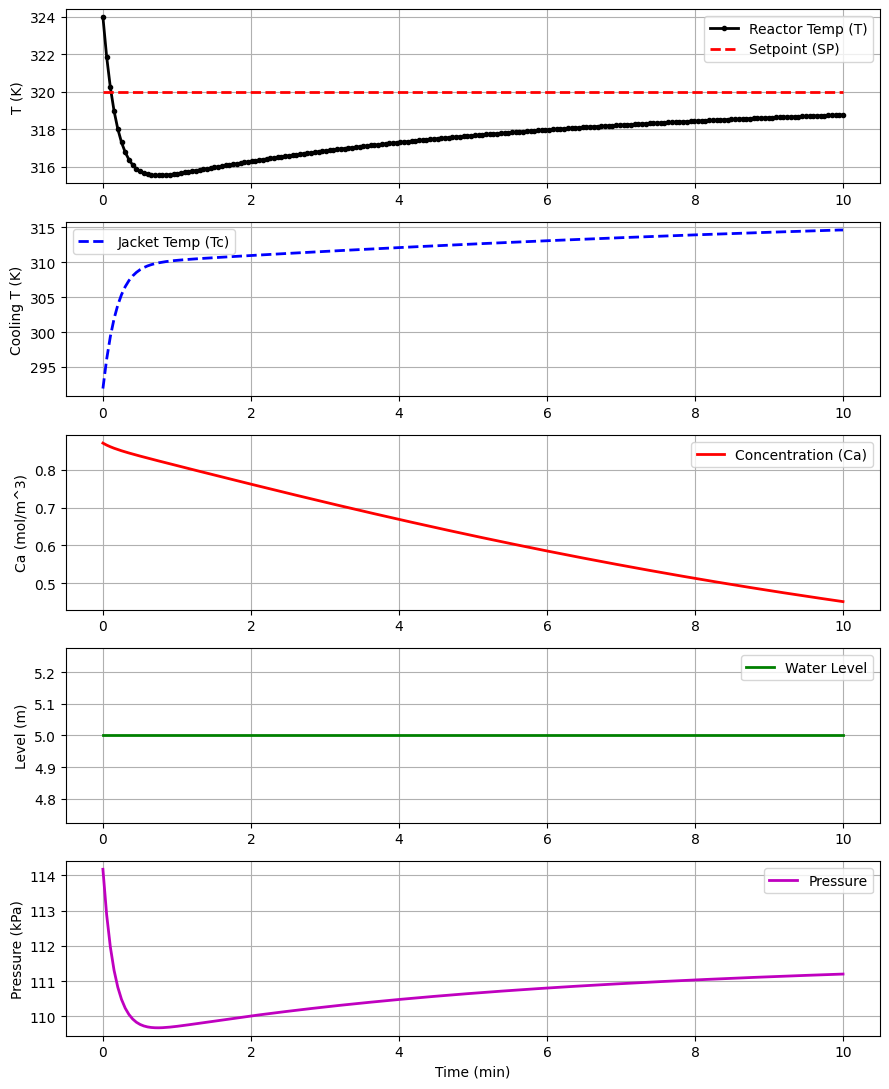

In [ ]:
# setting up initial conditions for states and feeds
Ca_ss = 0.87
T_ss = 324.0
V_ss = 100.0
x0 = np.array([Ca_ss, T_ss, V_ss])

Tf = 350.0
Caf = 1.0

# Time Grid
t = np.linspace(0, 10, 200)
dt = t[1] - t[0]

# variables (storage)
Ca = np.ones(len(t)) * Ca_ss
T = np.ones(len(t)) * T_ss
V = np.ones(len(t)) * V_ss
u = np.ones(len(t)) * 300.0

# controller variables
sp = np.ones(len(t)) * 320.0  # Desired target temperature = 320 K

Kp = 2
Ki = 0.5
Kd = 0

last_error = 0.0
integral = 0.0

# run simulation
for i in range(len(t) - 1):
    # Current state measurement
    current_T = x0[1]

    # Compute PID action for coolant jacket temperature u
    u[i], last_error, integral = pid_controller(
        sp[i], current_T, last_error, integral, dt, Kp, Ki, Kd
    )

    # Integrate forward over dt using current control action u[i]
    ts = [t[i], t[i+1]]
    y = odeint(cstr, x0, ts, args=(u[i], Tf, Caf))

    # Save outputs and update state for next step
    Ca[i+1] = y[-1][0]
    T[i+1] = y[-1][1]
    V[i+1] = y[-1][2]
    x0 = y[-1]

# Set final control signal state for plotting alignment
u[-1] = u[-2]

# Derived Variables
level = V / A_tank
pressure = get_pressure(T)

plt.figure(figsize=(9, 11))

plt.subplot(5, 1, 1)
plt.plot(t, T, 'k.-', linewidth=2, label='Reactor Temp (T)')
plt.plot(t, sp, 'r--', linewidth=2, label='Setpoint (SP)')
plt.ylabel('T (K)')
plt.legend(loc='best')
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(t, u, 'b--', linewidth=2, label='Jacket Temp (Tc)')
plt.ylabel('Cooling T (K)')
plt.legend(loc='best')
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(t, Ca, 'r-', linewidth=2, label='Concentration (Ca)')
plt.ylabel('Ca (mol/m^3)')
plt.legend(loc='best')
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(t, level, 'g-', linewidth=2, label='Water Level')
plt.ylabel('Level (m)')
plt.legend(loc='best')
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(t, pressure, 'm-', linewidth=2, label='Pressure')
plt.ylabel('Pressure (kPa)')
plt.xlabel('Time (min)')
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()
plt.show()